In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from astropy.io import ascii
import corner
from glob import glob
import torch
from emcee import EnsembleSampler
from pysynphot import BlackBody
from astropy.table import Table

import emcee
from pydusty.utils import get_extinction_corrected_fluxes


def init():
    matplotlib.rcParams['xtick.minor.size'] = 6
    matplotlib.rcParams['xtick.major.size'] = 8
    matplotlib.rcParams['ytick.major.size'] = 8
    matplotlib.rcParams['ytick.minor.size'] = 6
    matplotlib.rcParams['lines.linewidth'] = 1.0
    matplotlib.rcParams['axes.linewidth'] = 1.0
    matplotlib.rcParams['font.size']= 18
    matplotlib.rcParams['font.family']= 'sans-serif'
    matplotlib.rcParams['xtick.major.width']= 1.5
    matplotlib.rcParams['ytick.major.width']= 1.5
    matplotlib.rcParams['ytick.direction']='in'
    matplotlib.rcParams['xtick.direction']='in'

init()

/Users/viraj/anaconda3/envs/wntr23bzdiq/lib/python3.11/site-packages/pysynphot/locations.py:46: UserWarning: PYSYN_CDBS is undefined; functionality will be SEVERELY crippled.
  warnings.warn("PYSYN_CDBS is undefined; functionality will be SEVERELY "
/Users/viraj/anaconda3/envs/wntr23bzdiq/lib/python3.11/site-packages/pysynphot/locations.py:345: UserWarning: Extinction files not found in extinction
  warnings.warn('Extinction files not found in %s' % (extdir, ))


In [2]:
def normalize_pars(pars, min_vals, max_vals):
    return (pars - min_vals)/(max_vals - min_vals)


class Net(torch.nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fc1 = torch.nn.Linear(6, 16)
        self.fc2 = torch.nn.Linear(16, 32)
        self.fc3 = torch.nn.Linear(32, 64)
        self.fc4 = torch.nn.Linear(64, 64)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return x



class Dusty_r1_Net(torch.nn.Module):
    def __init__(self):
        super(Dusty_r1_Net, self).__init__()
        self.fc1 = torch.nn.Linear(6, 32)
        self.fc2 = torch.nn.Linear(32, 32)
        self.fc3 = torch.nn.Linear(32, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x


def calc_fnu(lam, lam_flam):
    c = 3e10
    nus = c / (lam * 1e-4)
    fnus = lam_flam * lam * 1e-4 / c
    return fnus

def calculate_scale(observed_wavs, observed_fluxes, observed_fluxerrs, model_wavs, model_fluxes):
    model_fluxes_interp = np.interp(x=observed_wavs, xp=model_wavs, fp=model_fluxes)
    # Calculate the weighted scale
    scale = np.sum(observed_fluxes * model_fluxes_interp / observed_fluxerrs ** 2) / np.sum(model_fluxes_interp ** 2 / observed_fluxerrs ** 2)
    return scale


def load_dusty_model(modelname):
    model = ascii.read(modelname)
    model['fnu'] = calc_fnu(lam=model['lam'], lam_flam=model['flux'])
    return model


def predict_dusty_model(net, dusty_pars):
    # Normalize the parameters first (array([2.5e+03, 3.0e+02, 2.0e-02, 2.0e-02, 2.0e+00]), array([6.5e+03, 1.0e+03, 2.0e-01, 1.0e-01, 1.0e+01]))
    # norm_pars = normalize_pars(pars=dusty_pars, min_vals=np.array([3.e+03, 6.e+02, 2.e-02, 1.e-02, 2.e+00, 6.e-01]),
    #                            max_vals=np.array([5.0e+03, 1.0e+03, 1.8e-01, 2.0e-01, 4.0e+01, 1.0e+00]))

    norm_pars = normalize_pars(pars=dusty_pars, min_vals=np.array([3300, 400, 0.01, 0.01, np.log10(2), 0.1]),
                               max_vals=np.array([4500, 1300, 0.2, 0.20, np.log10(50), 1.0])
                              )

    return 10**(net(torch.tensor(norm_pars).float()).detach().numpy() - 5)


def predict_dusty_log_r1(r1_net, dusty_pars):
    norm_pars = normalize_pars(pars=dusty_pars, min_vals=np.array([3300, 400, 0.01, 0.01, np.log10(2), 0.1]),
                               max_vals=np.array([4500, 1300, 0.2, 0.20, np.log10(50), 1.0])
                              )
    return r1_net(torch.tensor(norm_pars).float()).detach().numpy()

In [22]:
def calc_chisq(wavs, fnus, fnuerrs, model_wavs, scaled_model_fnus, error_underestimation_scaling=0):
    scaled_mrs_model_fnus = np.interp(mrs_spec['wavs'], xp=model_wavs, fp=scaled_model_fnus)
    chisq_mrs = np.sum((mrs_spec['fluxes'] - scaled_mrs_model_fnus)**2 / (mrs_spec['fluxerrs']**2 
                                                                          + error_underestimation_scaling*mrs_spec['fluxerrs']**2))

    scaled_miri_phot_model_fnus = np.interp(miri_phot['wavs'], xp=model_wavs, fp=scaled_model_fnus)
    chisq_miri_phot = np.sum((miri_phot['fluxes'] - scaled_miri_phot_model_fnus)**2 / (miri_phot['fluxerrs']**2 
                                                                                   + error_underestimation_scaling*miri_phot['fluxerrs']**2))

    scaled_opt_nir_model_fnus = np.interp(opt_nir_wavs, xp=model_wavs, fp=scaled_model_fnus)
    chisq_opt_nir_phot = np.sum((opt_nir_fluxes_jy - scaled_opt_nir_model_fnus)**2 / (opt_nir_fluxuncs_jy**2 
                                                                                   + error_underestimation_scaling*opt_nir_fluxuncs_jy**2))

    scaled_spherex_model_fnus = np.interp(spherex_spec_new['lambda'], xp=model_wavs, fp=scaled_model_fnus)
    chisq_spherex = np.sum((spherex_spec_new['flux'] - scaled_spherex_model_fnus)**2 / (spherex_spec_new['flux_err']**2))
    
    chisq = chisq_mrs/len(mrs_spec['wavs']) + chisq_miri_phot/len(miri_phot['wavs']) + chisq_opt_nir_phot/len(opt_nir_wavs) + chisq_spherex / len(spherex_spec_new['lambda'])
    return chisq


def calc_chisq_array(wavs, fnus, fnuerrs, model_wavs, scaled_model_fnus, error_underestimation_scaling=0):
    error_underestimation_scaling = 0.0
    
    scaled_mrs_model_fnus = np.interp(mrs_spec['wavs'], xp=model_wavs, fp=scaled_model_fnus)
    chisq_mrs = (mrs_spec['fluxes'] - scaled_mrs_model_fnus)**2 / (mrs_spec['fluxerrs']**2 
                                                                          + error_underestimation_scaling*mrs_spec['fluxerrs']**2)

    scaled_miri_phot_model_fnus = np.interp(miri_phot['wavs'], xp=model_wavs, fp=scaled_model_fnus)
    miri_phot_error_underestimation_scaling = 0.1
    chisq_miri_phot = (miri_phot['fluxes'] - scaled_miri_phot_model_fnus)**2 / (miri_phot['fluxerrs']**2 
                                                                                   + miri_phot_error_underestimation_scaling*miri_phot['fluxerrs']**2)

    scaled_opt_nir_model_fnus = np.interp(opt_nir_wavs, xp=model_wavs, fp=scaled_model_fnus)
    chisq_opt_nir_phot = (opt_nir_fluxes_jy - scaled_opt_nir_model_fnus)**2 / (opt_nir_fluxuncs_jy**2 
                                                                                   + error_underestimation_scaling*opt_nir_fluxuncs_jy**2)
    
    return chisq_mrs, chisq_miri_phot, chisq_opt_nir_phot


def calc_chisq_piecewise(wavs, fnus, fnuerrs, model_wavs, scaled_model_fnus, error_underestimation_scaling=0):
    scaled_inter_model_fnus = np.interp(x=wavs, xp=model_wavs, fp=scaled_model_fnus)
    chisq_array = (fnus - scaled_inter_model_fnus)**2 / (fnuerrs**2 + error_underestimation_scaling*fnus**2)
    return chisq_array

def unpack_parameters(theta, vary_ext, vary_error_underestimation):
    if not vary_ext and not vary_error_underestimation:
        Tstar, Tdust, tau, a, Y, si_abun = theta
        ebv = 0
        err_underestimation = 0

    elif vary_ext and vary_error_underestimation:
        Tstar, Tdust, tau, a, Y, si_abun, ebv, err_underestimation = theta

    elif vary_ext:
        Tstar, Tdust, tau, a, Y, si_abun, ebv = theta
        err_underestimation = 0

    else:
        Tstar, Tdust, tau, a, Y, si_abun, err_underestimation = theta
        ebv = 0
    return Tstar, Tdust, tau, a, Y, si_abun, ebv, err_underestimation

def unpack_5_parameters(theta, vary_ext, vary_error_underestimation):
    if not vary_ext and not vary_error_underestimation:
        Tstar, Tdust, tau, a, Y = theta
        ebv = 0
        err_underestimation = 0

    elif vary_ext and vary_error_underestimation:
        Tstar, Tdust, tau, a, Y, ebv, err_underestimation = theta

    elif vary_ext:
        Tstar, Tdust, tau, a, Y, ebv = theta
        err_underestimation = 0

    else:
        Tstar, Tdust, tau, a, Y, err_underestimation = theta
        ebv = 0
    return Tstar, Tdust, tau, a, Y, ebv, err_underestimation


def uniform_prior(theta, vary_ext=False, vary_error_underestimation=False):
    Tstar, Tdust, tau, a, log_Y, si_abun, ebv, err_underestimation = unpack_parameters(theta, vary_ext, vary_error_underestimation)
    if 3300 <= Tstar <= 4500 and 400 <= Tdust <= 1300 and 0.01 <= tau <= 0.2 and 0.01 < a  < 0.2 and 10 < 10**log_Y < 50 and  0.1 <= si_abun <= 1.0 and 0 <= ebv <=1 and 0 <= err_underestimation <= 0.05:
        return 0
        
    return -np.inf


def calc_integrated_flux(wavs_um, fnu_ujy):
    c = 3e10
    nus = c/(wavs_um*1e-4)
    fnu_ujy[fnu_ujy<0] = 0
    return np.trapz(x=nus, y=fnu_ujy*1e-29)*-1.0


def log_likelihood(theta, obs_wavs, obs_fnus, obs_fnuerrs, dusty_wavs, dusty_sed_net, dusty_r1_net, 
                   vary_ext=False, vary_error_underestimation=False, prior_func=uniform_prior):
    Tstar, Tdust, tau, a, log_Y, si_abun, ebv, err_underestimation = unpack_parameters(theta, vary_ext, vary_error_underestimation)
    prior = prior_func(theta, vary_ext, vary_error_underestimation)
    if not np.isfinite(prior):
        return -np.inf, np.nan, np.nan, np.nan
    ecor_obs_fnu, ecor_obs_fnuerrs = get_extinction_corrected_fluxes(mlam=obs_wavs, mlumobs=obs_fnus, merrobs=obs_fnuerrs, ebv=ebv)
    dusty_model_flux = predict_dusty_model(dusty_sed_net, np.array([Tstar, Tdust, tau, a, log_Y, si_abun]))
    dusty_model_fnu = calc_fnu(lam=dusty_wavs, lam_flam=dusty_model_flux)
    scale = calculate_scale(observed_wavs=obs_wavs, observed_fluxes=ecor_obs_fnu, observed_fluxerrs=ecor_obs_fnuerrs, model_wavs=dusty_wavs, model_fluxes=dusty_model_fnu)
    chisq = calc_chisq(obs_wavs, ecor_obs_fnu, ecor_obs_fnuerrs, dusty_wavs, dusty_model_fnu*scale, error_underestimation_scaling=err_underestimation)

    int_flux = calc_integrated_flux(dusty_wavs, dusty_model_fnu*scale)

    log_r1 = predict_dusty_log_r1(dusty_r1_net, np.array([Tstar, Tdust, tau, a, log_Y, si_abun]))[0]

    return -0.5 * chisq, scale, int_flux, log_r1


In [25]:
def get_lums_r1s(blobs, dist_mpc):
    int_fluxes = blobs[:,1]
    int_lums = int_fluxes * 4*np.pi*(dist_mpc*3.086e24)**2 * 1e6
    log_r1s = blobs[:,2]
    log_scaled_r1s = log_r1s + 0.5*np.log10(int_lums/3.83e37)
    return int_lums, log_scaled_r1s

In [26]:
def get_dusty_r1_value(dusty_filename):
    with open(dusty_filename, 'r') as f:
        dat = f.readline()
    return float(dat.split('#')[1].strip('\n'))

In [ ]:
def run_mcmc(obs_wavs, obs_fnus, obs_fnuerrs, dusty_wavs, dusty_sed_net, dusty_r1_net, 
             vary_ext=False, use_error_underestimation=False, plot_label='sed', nsteps=1000, 
             plot = True, prior_func=uniform_prior):
    nwalkers = 32
    ndim = 6
    initial = np.array([3900, 800, 0.11, 0.1, np.log10(20), 0.5])
    inital_std = np.array([100, 50, 0.01, 0.01, 0.1, 0.01])
    labels = ['Tstar','Tdust','tau', 'a','log_Y', 'si_abun']
    if vary_ext:
        ndim += 1
        initial = np.append(initial, 0.05)
        inital_std = np.append(inital_std, 0.01)
        labels.append('ebv')
    if use_error_underestimation:
        ndim += 1
        initial = np.append(initial, 0.01)
        inital_std = np.append(inital_std, 0.01)
        labels.append('ferr')

    sampler = emcee.EnsembleSampler(nwalkers=nwalkers, ndim=ndim, log_prob_fn=log_likelihood, 
                                    blobs_dtype=float, args=[obs_wavs, obs_fnus, obs_fnuerrs, 
                                                             dusty_wavs, dusty_sed_net, dusty_r1_net, 
                                                             vary_ext, use_error_underestimation, prior_func])

    inital_pos = initial + inital_std * np.random.randn(nwalkers, ndim)
    sampler.run_mcmc(inital_pos, nsteps, progress=True)

    if plot:
        flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
        blobs = sampler.get_blobs(discard=100, thin=15, flat=True)
        int_lums, log_scaled_r1s = get_lums_r1s(blobs, 0.77)
        flat_samples_extend = np.hstack((flat_samples, np.log10(int_lums[:, None]), log_scaled_r1s[:, None]))
        labels = labels + ['log_Lint', 'log_scaled_r1']
        fig = corner.corner(flat_samples_extend, labels=labels, show_titles=True)
        
        plt.figure()
        randinds = np.random.choice(np.arange(len(flat_samples)), 100)
        for ind in randinds:
            Tstar, Tdust, tau, a, log_Y, si_abun, _, _ = unpack_parameters(flat_samples[ind], vary_ext, use_error_underestimation)
            dusty_model_flux = predict_dusty_model(net, np.array([Tstar, Tdust, tau, a, log_Y, si_abun]))
            dusty_model_fnu = calc_fnu(lam=dusty_wavs, lam_flam=dusty_model_flux)
            scale = calculate_scale(observed_wavs=obs_wavs, observed_fluxes=obs_fnus, observed_fluxerrs=obs_fnuerrs, model_wavs=dusty_wavs, model_fluxes=dusty_model_fnu)
            plt.plot(dusty_wavs, dusty_model_fnu*scale, alpha=0.1, color='orange')
        plt.errorbar(y=obs_fnus, yerr=obs_fnuerrs, x=obs_wavs, fmt='o', color='black')

        plt.yscale('log')
        plt.xscale('log')
        plt.xlabel(r'$\lambda$ [$\mu$m]')
        plt.ylabel(r'Flux density [$\mu$Jy]')
    return sampler

In [11]:
net = Net()
net.load_state_dict(torch.load('../dusty_models/dusty_model_6pars_logY_predictor.pth'))

r1_net = Dusty_r1_Net()
r1_net.load_state_dict(torch.load('../dusty_models/dusty_model_r1_6pars_logY_predictor.pth'))
dusty_model_wavs = ascii.read('../dusty_models/sed_3800_600_0.06999999999999999_0.1_5.0_silow_0.5_enstatite_0.5_0.55um.dat')['lam']
dusty_model_wavs = dusty_model_wavs[(dusty_model_wavs>=0.1) & (dusty_model_wavs<=50.0)]


In [12]:
opt_nir_wavs = np.array([0.355, 0.477, 0.623, 0.762, 1.235, 1.662, 2.159])
opt_nir_mags = np.array([18.495  ,15.753, 14.336, 13.971, 12.64 + 0.89, 12.17 + 1.39 , 11.92+1.85])
opt_nir_magerrs = np.array([0.092, 0.027, 0.019,  0.024, 0.075, 0.091, 0.09])
opt_nir_fluxes_jy = 10**(-0.4*opt_nir_mags)*3631
opt_nir_fluxuncs_jy = opt_nir_magerrs/1.086 * opt_nir_fluxes_jy

In [18]:
miri_phot = ascii.read('../observational_data/at2025abao_jwst_miri_photometry.csv')
miri_phot['fluxes'] *=1e-6
miri_phot['fluxerrs'] *=1e-6
mrs_spec_full = ascii.read('../observational_data/at2025abao_jwst_miri_mrs_spectrum.csv')
mrs_spec = mrs_spec_full[(mrs_spec_full['wavs']<17)]

spherex_spec_new = pd.read_csv('../observational_data/spherex_epoch2.csv')


In [31]:
sampler = run_mcmc(obs_wavs=mrs_spec['wavs'], obs_fnus=mrs_spec['fluxes'], obs_fnuerrs=mrs_spec['fluxerrs'],
         dusty_wavs=dusty_model_wavs,
         dusty_sed_net=net,
         dusty_r1_net=r1_net,
         vary_ext=False, use_error_underestimation=True,
         plot_label='mrs', nsteps=1000, plot = False, prior_func=uniform_prior)

  0%|          | 0/1000 [00:00<?, ?it/s]/Users/viraj/anaconda3/envs/wntr23bzdiq/lib/python3.11/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 1000/1000 [11:46<00:00,  1.42it/s]


In [32]:
flat_samples = sampler.get_chain(discard=100, thin=15, flat=True)
blobs = sampler.get_blobs(discard=100, thin=15, flat=True)
int_lums, log_scaled_r1s = get_lums_r1s(blobs, 0.77)
# add lums and r1s to corner plot
flat_samples_extend = np.hstack((flat_samples[:, :-1], int_lums[:, None]/3.83e33, log_scaled_r1s[:, None]))
flat_samples_extend[:, 4] = 10**flat_samples_extend[:, 4]
labels = labels=['Tstar [K]','Tdust [K]',r'$\tau_V$', '$a$ [$\mu$m]', 'Y', r'$a_{\rm{silow}}$',r'L [L$_{\odot}$]', r'log(r$_{\rm{dust,in}}$/cm)']

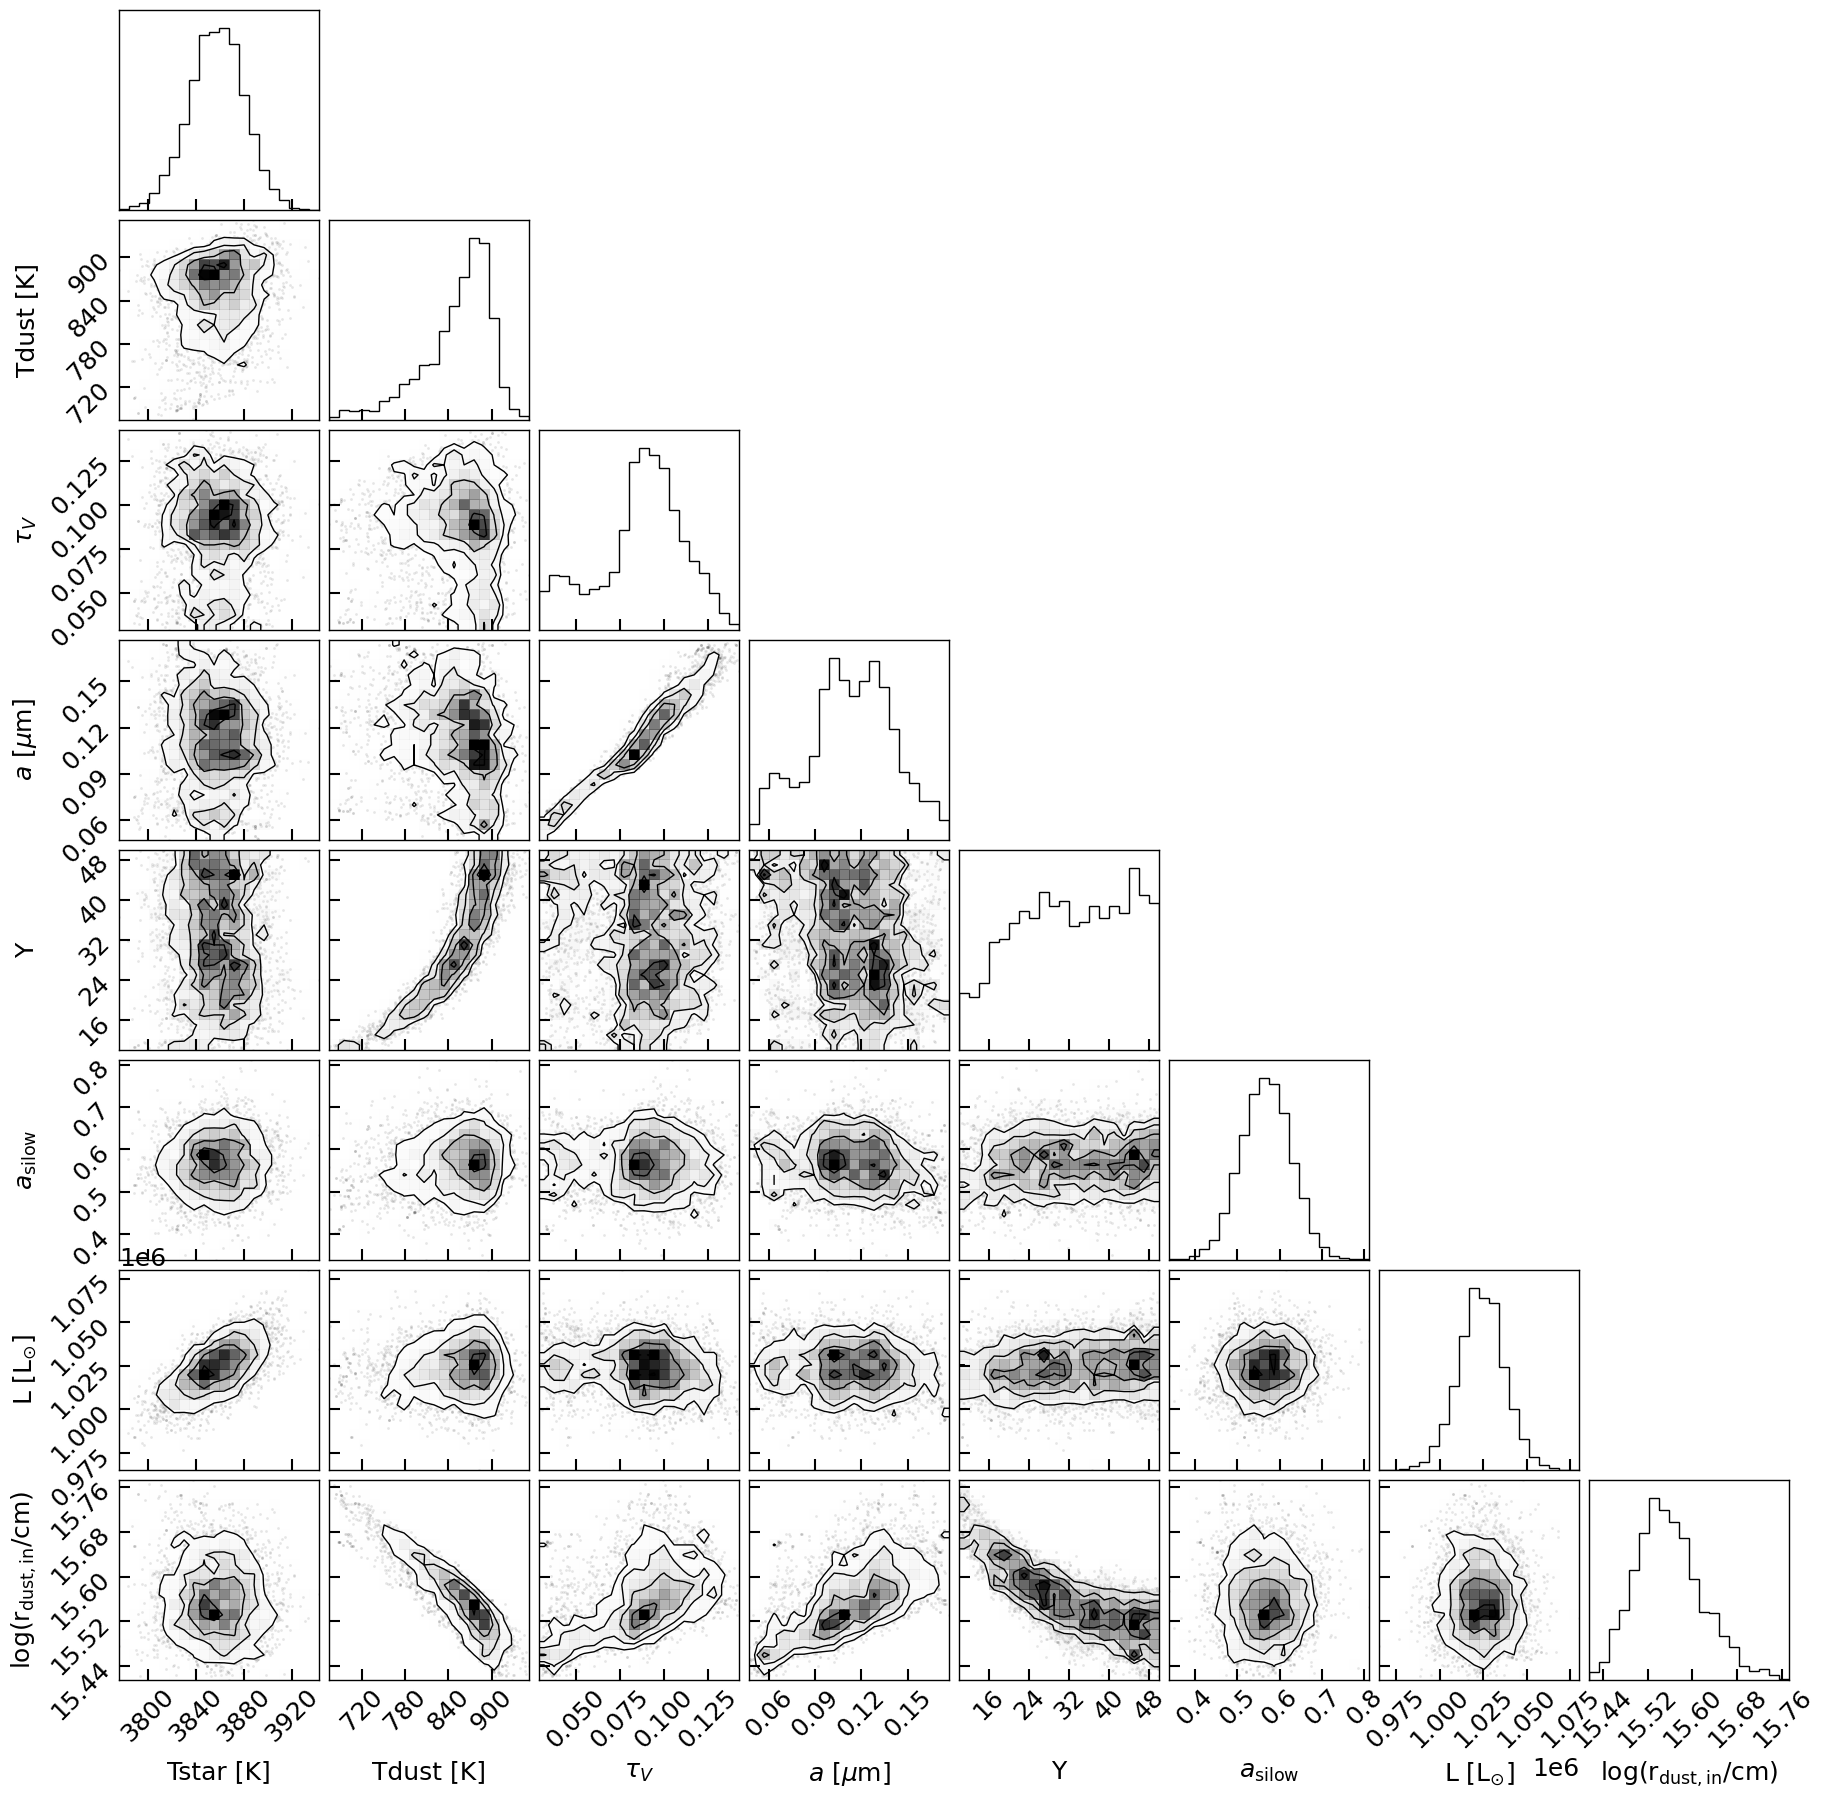

In [ ]:
fig = corner.corner(flat_samples_extend, labels=labels, show_titles=False, labelpad=0.1)
